<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" style="width: 30%;">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II


## Deslocamentos transversais de vigas

### Problema 3

A figura representa a viga ABC, à qual está ligada a barra BDE. Sobre a viga está aplicada a carga distribuída triangular $Q(x)$ e sobre a barra exerce-se a força concentrada $P$.  Sabendo que $Q_C =$ 20 kN/m, $P =$ 40 kN, $L =$ 12 m e considerando apenas a viga ABC determine:

a) As reações nos apoios A e C.

b) Utilizando funções de singularidade escreva a equação do momento fletor na viga.

c) Trace os diagramas do esforço transverso e do momento fletor na viga.

d) Determine a equação da linha elástica.


<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au09/P3/MSII_Au09_P3.png"
style="width: 40%;"/>

In [1]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '1'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr2.atoms(sy.Number)})

# data structure, units: N, mm, MPa

class varin: pass

d = varin()

d.L = 12.  # unit: m
d.QC = 20.  # unit: m
d.P = 40.  # unit: m
d.EI = 7.38e6 # N.m²

def printsymSF(expr):
    expr2 = sy.simplify(sy.factor(expr))
    return expr2.xreplace({n : round(n, 3) for n in expr.atoms(sy.Number)})

### Resolução

- 1 ::: sistema força-binário equivalente

\begin{equation*}
P_B = P
\quad\wedge\quad
M_B = P\left(\frac{L}{3}\right)
\end{equation*}

In [2]:
print(f':: sistema força-binário equivalente ::')
PB = d.P
print(f'PB = {PB:.1f} [kN]')

MB = d.P*d.L/3
print(f'MB = {MB:.1f} [kN.m]')

:: sistema força-binário equivalente ::
PB = 40.0 [kN]
MB = 160.0 [kN.m]


- Carga distribuida triangular

\begin{equation*}
Q(x) = m x
\quad\wedge\quad
m = \frac{Q_C}{L}
\end{equation*}

tendo como carga resultante equivalente e linha de acção sobre o centroide da área,

\begin{equation*}
Q_{eq} = \int_0^L \frac{Q_C}{L} x~\mathrm{d}x
\quad\wedge\quad
\overline{x} =
\left( \int_0^L \frac{Q_C}{L} x~\mathrm{d}x \right) / Q_{eq}
\end{equation*}


In [3]:
x = sy.symbols('x')

def qtri(x): return d.QC/d.L*x

print(f'Q(x) = {printsymSF(qtri(x))} [kN]')

qtri_eq = sy.integrate(qtri(x),(x,0,d.L))
print(f'qtri_eq = {qtri_eq:.1f} [kN]')
qtri_xcent = 2/3*d.L
print(f'qtri_xcent (por formulário) = {qtri_xcent} [m]')
iiaux = sy.integrate(qtri(x)*x,(x,0,d.L))
qtri_xcent2 = iiaux/qtri_eq
print(f'qtri_xcent (por integração) = {qtri_xcent2:.1f} [m]')

Q(x) = 1.667*x [kN]
qtri_eq = 120.0 [kN]
qtri_xcent (por formulário) = 8.0 [m]
qtri_xcent (por integração) = 8.0 [m]


- 2 ::: cálculo das reações

\begin{equation*}
\sum F_x = 0
\quad\wedge\quad
\sum F_y = 0
\quad\wedge\quad
\sum M_A = 0
\end{equation*}

In [4]:
rax, ray, rdy = sy.symbols('rax ray rdy')

print('::: sistema de equações :::')
sumFX = rax
print(f'sumFX = {sumFX} [kN]')
sumFY = ray + rdy - PB - qtri_eq
print(f'sumFY = {sumFY} [kN]')
sumMA= -qtri_eq*qtri_xcent + rdy*d.L + MB - PB*2/3*d.L
print(f'sumMA = {sumMA} [kN.m]')
sol = solve([sumFX,sumFY,sumMA],[rax, ray, rdy])

print('::: resolução :::')
RAx = sol[rax]; print(f'RAx = {RAx} [kN]')
RAy = sol[ray]; print(f'RAy = {RAy:.1f} [kN]')
RDy = sol[rdy]; print(f'RRy = {RDy:.1f} [kN]')

::: sistema de equações :::
sumFX = rax [kN]
sumFY = ray + rdy - 160.0 [kN]
sumMA = 12.0*rdy - 1120.0 [kN.m]
::: resolução :::
RAx = 0.0 [kN]
RAy = 66.7 [kN]
RRy = 93.3 [kN]


- 0 ::: Formulário

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au09/P1/MSII_Au09_P1_formulario.png"
width="900"/>

- **1.1 :::** Funções de singularidade para as expressões do esforço transverso e momento fletor associado a $R_{Ay}$

\begin{equation*}
V(x) | R_{Ay} = R_{Ay} <x-0>^0  = R_{Ay}
\quad\wedge\quad
M(x) | R_{Ay} = R_{Ay} <x-0>^1  = R_{Ay} x
\end{equation*}

In [5]:
V1, M1 = RAy, RAy*x
print(f'V1 = {V1:.1f} [kN]')
print(f'M1 = {printsymSF(M1)} [kN.m]')

V1 = 66.7 [kN]
M1 = 66.667*x [kN.m]


- **1.2 :::** Funções de singularidade para as expressões do esforço transverso e momento fletor associado a $P_B$

\begin{equation*}
V(x)| P_B = -P_B <x-\frac{2}{3}L>^0
\quad\wedge\quad
M(x) | P_B = -P_B <x-\frac{2}{3}L>^1
\end{equation*}

In [6]:
V2 = -PB*(x-2/3*d.L)**0
M2 = -PB*(x-2/3*d.L)**1
print(f'V2 = {V2:.1f} [kN]')
print(f'M2 = {M2} [kN.m]')

V2 = -40.0 [kN]
M2 = 320.0 - 40.0*x [kN.m]


- **1.3 :::** Funções de singularidade para as expressões do esforço transverso e momento fletor associado a $M_B$

\begin{equation*}
V(x)| {M_B} = 0
\quad\wedge\quad
M(x)| {M_B} = -M_B <x-\frac{2}{3}L>^0
\end{equation*}

In [7]:
V3, M3 = 0, -MB*(x-2/3*d.L)**0
print(f'V3 = {V3:.1f} [kN]')
print(f'M3 = {M3:.1f} [kN.m]')

V3 = 0.0 [kN]
M3 = -160.0 [kN.m]


- **1.4 :::** Funções de singularidade para as expressões do esforço transverso e momento fletor associado ao carregamento triangular

\begin{equation*}
V(x)| {\mathrm{triang}} = -\frac{m}{2} <x-\frac{2}{3}L>^2
\quad\wedge\quad
M(x)| {\mathrm{triang}} = -\frac{m}{(2)(3)} <x-\frac{2}{3}L>^3
\quad\wedge\quad
m = \frac{Q_C}{L}
\end{equation*}

In [8]:
mt = d.QC/d.L
V4 = -mt/2*(x-2/3*d.L)**2
M4 = -mt/2/3*(x-2/3*d.L)**3
print(f'V4 = {printsymSF(V4)} [kN]')
print(f'M4 = {printsymSF(M4)} [kN.m]')

V4 = -53.333*(0.125*x - 1.0)**2 [kN]
M4 = -142.222*(0.125*x - 1.0)**3 [kN.m]


- Esforço tranverso

\begin{equation*}
V(x) = R_{Ay} -P_B <x-\frac{2}{3}L>^0
-\frac{Q_C}{L} x^2
\quad\mathrm{[kN]}
\end{equation*}

- Momento fletor

\begin{equation*}
M(x) = R_{Ay} x -P_B <x-\frac{2}{3}L>^1
-M_B <x-\frac{2}{3}L>^0
-\frac{Q_C/L}{(2)(3)} x^3
\quad\mathrm{[kN.m]}
\end{equation*}

In [9]:
VAB = RAy - d.QC/d.L/2*x**2
VBC = RAy - PB - d.QC/d.L/2*x**2

MAB = RAy*x - d.QC/d.L/6*x**3
MBC = RAy*x - PB*(x-2/3*d.L) - MB - d.QC/d.L/6*x**3

xAB = np.linspace(0,2/3*d.L)
xBC = np.linspace(2/3*d.L,d.L)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB = sy2array(VAB,xAB)
yMAB = sy2array(MAB,xAB)

# BC
yVBC = sy2array(VBC,xBC)
yMBC = sy2array(MBC,xBC)

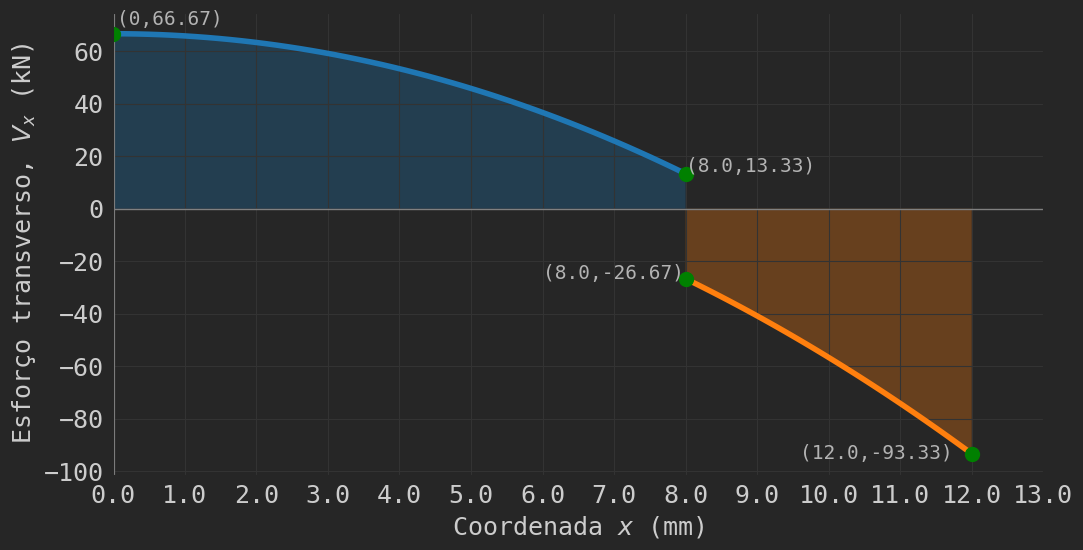

In [10]:
fz = 14

fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB,yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4)
plt.fill_between(xBC,yVBC, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0]+.05,yVAB[0]*1.05,f'({xAB[0]:.0f},{yVAB[0]:.2f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.,yVAB[-1]*1.05,f'({xAB[-1]:.1f},{yVAB[-1]:.2f})',
         fontsize=fz)
plt.plot(xBC[0],yVBC[0],'go',markersize=10)
plt.text(xBC[0]*.75,yVBC[0]*1.,f'({xBC[0]:.1f},{yVBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*.8,yVBC[-1]*1.02,f'({xBC[-1]:.1f},{yVBC[-1]:.2f})',
         fontsize=fz)
plt.xlim(0,d.L*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.L*1.1, 1.)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

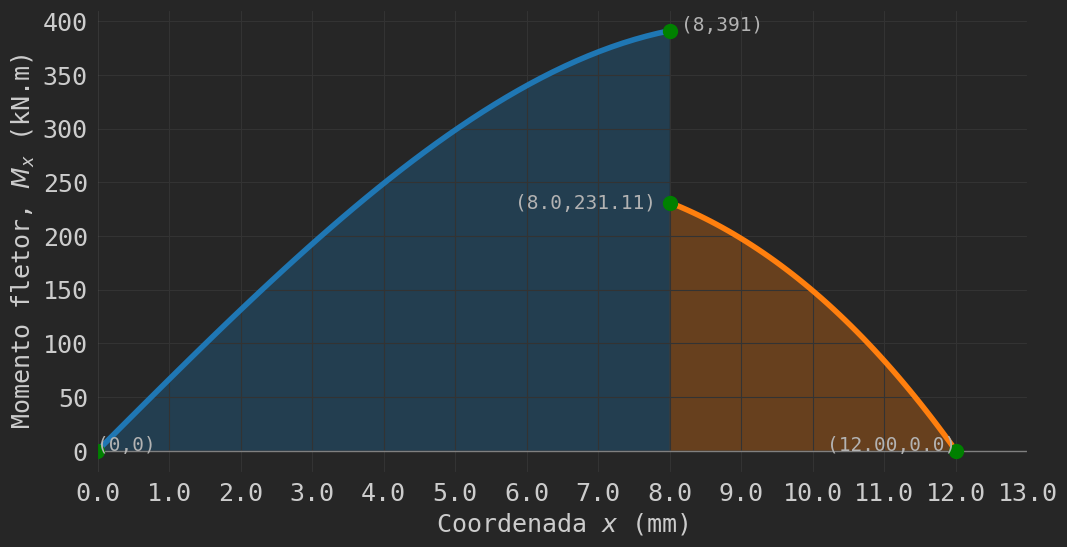

In [11]:
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB,yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4)
plt.fill_between(xBC,yMBC, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0],yMAB[0]+.1,f'({xAB[0]:.0f},{yMAB[0]:.0f})',fontsize=fz)
plt.plot(xAB[-1],yMAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.02,yMAB[-1]+.1,f'({xAB[-1]:.0f},{yMAB[-1]:.0f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.text(xBC[0]*.73,yMBC[0]*.975,f'({xBC[0]:.1f},{yMBC[0]:.2f})',fontsize=fz)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
plt.text(xBC[-1]*.85,yMBC[-1],f'({xBC[-1]:.2f},{yMBC[-1]:.1f})', fontsize=fz)
plt.xlim(0,d.L*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.arange(0, d.L*1.1, 1.0)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

- **3 :::** Equação da linha elástica:

\begin{equation*}
\frac{\partial² y(x)}{\partial x²} \equiv \frac{\partial² v(x)}{\partial x²}  = \frac{M(x)}{EI}
\end{equation*}

com,

\begin{equation*}
M(x) = R_{Ay} x -P_B <x-\frac{2}{3}L>^1
-M_B <x-\frac{2}{3}L>^0
-\frac{Q_C/L}{(2)(3)} x^3
\end{equation*}

por integração, obtem-se

\begin{equation*}
EI\theta(x) = R_{Ay} \frac{x²}{2} - \frac{P_B}{2} <x-\frac{2}{3}L>^2
-M_B <x-\frac{2}{3}L>^1
-\frac{Q_C/L}{24} x^4 + C_1
\end{equation*}

integrando novamente resulta

\begin{equation*}
EIv(x) = R_{Ay} \frac{x³}{6} - \frac{P_B}{6} <x-\frac{2}{3}L>^3
-\frac{M_B}{2} <x-\frac{2}{3}L>^2
-\frac{Q_C/L}{120} x^5 + C_1 x + C_2
\end{equation*}

As constantes de integração $C_1$ e $C_2$ são determinadas pelas condições de fronteira.

\begin{equation*}
x = 0 \quad\Rightarrow\quad y(0) = 0
\quad\therefore\quad C_2 = 0
\end{equation*}

\begin{equation*}
x = L \quad\Rightarrow\quad y(L) = 0
\quad\therefore\quad
R_{Ay} \frac{L³}{6} - \frac{P_B}{6} (L-\frac{2}{3}L)^3
-\frac{M_B}{2} (L-\frac{2}{3}L)^2
-\frac{Q_C/L}{120} L^5 + C_1 L = 0
\end{equation*}

In [12]:
c1, c2 = sy.symbols('c1 c2')

print('::: eq. cond. fronteira :::')

def flex(x):
    if x == 0:
        t1, t3, t4 = 0, 0, 0
        t2 = RAy/6*x**3
    else:
        t1 = RAy/6*x**3
        t2 = - PB/6*(x-2/3*d.L)**3
        t3 = - MB/2*(x-2/3*d.L)**2
        t4 = - (d.QC/d.L/120)*x**5
    return t1 + t2 + t3 + t4 + c1*x + c2

eqC1 = flex(0.)
print(f'eqC2 = {eqC1}')
sol = solve(eqC1,c2)
C2 = sol[0]
print(f'C2 = {C2} ')

eqC2 = flex(d.L).subs(c2,C2)
print(f'eqC2 = {printsymSF(eqC2)} [kN.m]')
sol = solve(eqC2,c1)
C1 = sol[0]
print(f'C1 = {C1:.3f} ')

def eitheta_(x):
    return sy.diff(flex(x).subs({(c1,C1),(c2,C2)}),x)

def eiy_(x):
    return flex(x).subs({(c1,C1),(c2,C2)})


::: eq. cond. fronteira :::
eqC2 = c2
C2 = 0 
eqC2 = 12.0*c1 + 14037.333 [kN.m]
C1 = -1169.778 


### Apêndice: Equação da elástica

A equação $y(x)$ descreve a localização do eixo da viga na posição deformada pela acção do momento fletor. Esta equação é conhecida como equação da linha elástica, e pode ser obtida na prática por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar nomeadamente as constantes de integração resultantes do processo matemática de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo ainda a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$ e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d}x²}
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d} x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, M(x) - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.

### Apêndice A: Equação da elástica

A equação $y(x)$ descreve a posição deformada do eixo da viga devido à ação do momento fletor. Esta equação é conhecida como a equação da linha elástica e pode ser obtida na prática através da solução de uma equação diferencial por dupla integração da equação do momento fletor ao longo da viga. A equação resultante deve ainda satisfazer as condições de fronteira do problema, ou seja, ser cinematicamente admissível. Esta condição permitirá determinar, nomeadamente, as constantes de integração resultantes do processo de integração.

A hipótese de Euler-Bernoulli para o problema de flexão de uma viga conduz à seguinte equação,

\begin{equation*}
\varepsilon_{xx} = -\frac{y}{\rho}
\end{equation*}

Assumindo ainda a lei de Hooke para o comportamento linear elástico do materia, $\sigma_{xx} = E \varepsilon_{xx}$, pode obter-se uma relação entre o momento flector $M(x)$ e o raio de curvatura da superfície neutra da viga $\rho$,

\begin{equation*}
\sigma_{xx} = E \varepsilon_{xx} =
-\frac{yE}{\rho}
\quad\wedge\quad
\sigma_{xx} = -\frac{My}{I_z}
\quad\therefore\quad
\frac{1}{\rho} = \frac{M}{EI_z}
\end{equation*}

Considerando agora a relação entre o raio de curvatura $\rho$ e as segundas derivadas da função $y(x)$, que para pequenos valroes resulta,

\begin{equation*}
\frac{1}{\rho} \approx \frac{\mathrm{d}² y}{\mathrm{d} x²}
\end{equation*}

obtém-se finalmente,

\begin{equation*}
\frac{\mathrm{d}² y}{\mathrm{d} x²}
= \frac{M}{EI_z}
\end{equation*}

Assim sendo, para se obter a equação da elástica da viga do problema, $y(x)$, é necessário:

1. Escrever a equação do momento fletor na viga, $M(x)$ - nomeadamente usando funções de singularidasde;

2. Integrar duas vezes essa equação;

3. Aplicar condições fronteira para calcular as duas constantes que surgem durante a integração.


### Apêndice B: Funções de singularidade

As expressões $⟨x − a⟩^0$, $⟨x − a⟩^1$, $⟨x − a⟩^2$ são designadas por funçoes singulares. Quando $n ≥ 0$,

\begin{equation*}
⟨x − a⟩^n = 
\begin{cases}
(x − a)^n & \quad\text{se } x \ge a \\
0 & \quad\text{se } x < a \\
\end{cases}
\end{equation*}

Nota-se que, os parênteses angulares ⟨ ⟩ devem ser substituídos por parênteses curvos ( ) quando $x ≥ a$ e por zero quando $x < a$.

Segue da definição de funções singularidades que,

\begin{equation*}
\int ⟨x − a⟩^n \mathrm{d}x = \frac{1}{n+1} 
⟨x − a⟩^{n+1} \quad\textrm{se}\quad n \ge 0
\end{equation*}

e 

\begin{equation*}
\frac{d}{dx} ⟨x − a⟩^n = n⟨x − a⟩^{n-1} \quad\textrm{se}\quad n \ge 1
\end{equation*}

### Anexo: Funções de singularidade

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Formulario/singularity_functions.png"
width="900">

---

Copyright (c) DEMI - FCT NOVA

Interactive computing by <a href="https://jupyter.org/" target="_blank"> <span
style="color:#333399"> Jupyter Notebook </span> </a> &nbsp;|&nbsp;Coded by <a href = "mailto: jmc.xavier@fct.unl.pt">José Xavier</a>

Licensed under  <a href="http://creativecommons.org/licenses/by-sa/4.0/"
target="_blank"> <span style="color:#333399;font-size: 20px"> CC BY-SA 4.0  </span></a>